# Solve PROCESS equilibrium as an IVP

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
from process.main import SingleRun
import process.impurity_radiation as impurity_radiation
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import solve_ivp
import process.data_structure.physics_variables as pv
import process.data_structure.impurity_radiation_module as irm
import pandas as pd
import process.data_structure
import os

Running scipy's SLSQP


Initial LT optimisation problem solved, evaluation problem produced (from `failure-uq/design_point`): `lt_sol_IN.DAT` copied here.

Evaluation (optimisation and evaluation problem produce the same):\
te = 1.12681909099069344e+01, ne = 8.40115207392886620e+19\
Use this evaluation input file for testing solving Process as an IVP problem.

In [2]:
# Set up
input_file = "data/lt_sol_IN.DAT"
single_run = SingleRun(input_file)
# Control vars to move solution vector
P_HCD_PRIMARY_EXTRA_HEAT_MW = 75.0
MOLFLOW_PLASMA_FUELLING_REQUIRED = 7.5e21


# Evaluation derivatives
def eval_process(te, ne, pinj, rfuel, fw, triang):
    single_run = SingleRun(input_file)
    # Loading single run overwrites variables: set again
    process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = pinj
    pv.molflow_plasma_fuelling_required = rfuel
    process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
        13
    ] = fw
    pv.triang = triang

    # Solution vector
    pv.temp_plasma_electron_vol_avg_kev = te
    pv.nd_plasma_electrons_vol_avg = ne
    # Clear all output, but show exceptions
    try:
        single_run.run()
        clear_output()
    except:
        clear_output()
        raise

    # raise Exception
    return (
        process.constraints.constraint_equation_2().constraint_error,
        process.constraints.constraint_equation_93().constraint_error,
    )


# clear_output()
eval_process(te=9.0, ne=8.0e19, pinj=75, rfuel=7.5e21, fw=5.0e-6, triang=0.5)

(0.016114379798638924, 1.9106743704952997e+21)

Define IVP problem.

In [3]:
# Debug only
output_path = "ivp_iterations.csv"
log_path = "iterations.log"
conv_crit_path = "conv_crit.csv"
try:
    Path(output_path).unlink()
    Path(log_path).unlink()
    Path(conv_crit_path).unlink()
except:
    pass

# Nondimensionalisation
te0 = 10.0
ne0 = 1.0e20
t0 = 2.0e2
scaling = np.array([te0, ne0])


def derivatives(t, y, pinj, rfuel, fw, triang):
    # Scale up to real values
    y_real = y * scaling
    te = y_real[0]
    ne = y_real[1]

    # Debug
    # with open(log_path, "a") as f:
    #     print(f"{t = }, {te = }, {ne = }", file=f)

    # Evaluate PPB and Fuel Equilibrium
    ppb, fe = eval_process(te, ne, pinj, rfuel, fw, triang)

    ni = pv.nd_plasma_ions_total_vol_avg
    vol = pv.vol_plasma
    dte_dt = (
        (2 / 3) * (1 / 1.602e-19) * ((ppb * 1e6 * vol) / ((ni + ne) * vol))
    ) * 1e-3
    # Could Gauss-Siedel here: re-run with updated Te?
    # New dne_dt form
    # dne_dt = fe / vol
    zimp = 0.0
    for imp in range(irm.N_IMPURITIES):
        if irm.impurity_arr_z[imp] > 2:
            zimp += (
                impurity_radiation.zav_of_te(
                    imp, np.array([pv.temp_plasma_electron_vol_avg_kev])
                ).squeeze()
                * (irm.f_nd_impurity_electron_array[imp])
            )
    f_alpha = pv.nd_plasma_alphas_vol_avg / ne
    dne_dt = (fe / vol) / (1 - pv.f_nd_beam_electron - zimp - 2 * f_alpha)

    # Debug
    print(f"{pv.f_nd_beam_electron = }")
    print(f"{zimp = }")

    # Debugging df
    data = {"t": [t], "te": [te], "ne": [ne], "dte_dt": [dte_dt], "dne_dt": [dne_dt]}
    # Only write a header when the file is first created
    pd.DataFrame(data).to_csv(
        output_path,
        mode="a",
        header=not os.path.exists(output_path),
        index=False,
        float_format="%.9e",
    )

    # Scale back down to nondimensionalised values
    return np.array([dte_dt, dne_dt]) * t0 / scaling


def detect_steady_state(t, y, pinj, rfuel, fw, triang):
    # Terminate integration when d/dts below tolerance (crosses 0)
    # 5.0e-3 is pretty flat
    # 1.0e-2 still a gradient
    tol = 5.0e-3
    d_dts = derivatives(t, y, pinj, rfuel, fw, triang)
    crit = np.sqrt(d_dts[0] ** 2 + d_dts[1] ** 2) - tol

    # DEBUG
    data = {"crit": [crit]}
    pd.DataFrame(data).to_csv(
        conv_crit_path,
        mode="a",
        header=not os.path.exists(output_path),
        index=False,
        float_format="%.9e",
    )
    return crit


detect_steady_state.terminal = True

# Parameters to vary
pinj = P_HCD_PRIMARY_EXTRA_HEAT_MW
rfuel = MOLFLOW_PLASMA_FUELLING_REQUIRED
fw = 5.0e-6
triang = 0.5

time_span = np.array([0.0, 1.0e3]) / t0

In [5]:
initial_values = np.array([10.5, 9.0e19]) / scaling

# TEST: next-to-no fuelling
# rfuel = 1.0
# Radau required due to "stiffness": very different timescales of dte/dt and dne/dt
sol = solve_ivp(
    fun=derivatives,
    args=(pinj, rfuel, fw, triang),
    t_span=time_span,
    y0=initial_values,
    method="Radau",
    events=detect_steady_state,
)
print(f"{initial_values = }")
y_real = sol.y * scaling[:, np.newaxis]
t_real = sol.t * t0
print(f"Equilibrium values = [{y_real[0, -1]}, {y_real[1, -1]}]")
print(sol.message)

pv.f_nd_beam_electron = 0.0
zimp = 0.04332806881016533
initial_values = array([1.05, 0.9 ])
Equilibrium values = [11.26311704795079, 8.407555163510705e+19]
A termination event occurred.


### Test unit corrections
Test some values for te and ne equations. Te:

In [ ]:
temp_ev = (
    (2 / 3)
    * (1 / 1.602e-19)
    * (
        pv.e_plasma_beta_thermal
        / (
            (pv.nd_plasma_ions_total_vol_avg + pv.nd_plasma_electrons_vol_avg)
            * pv.vol_plasma
        )
    )
)
print(temp_ev)

12385.609499605556


12 keV value from the dte/dt equation agrees well with the vol avg Te from Process. Now check ne:

In [ ]:
ne_test = pv.nd_plasma_fuel_ions_vol_avg
print(ne_test)

7.2168138370191426e+19


The static value for ne is similar, but not correct (disagrees with Process output) as n_alpha, n_imp etc. are also included. But for dne/dt = dn_fuel/dt it is correct, as all other values assumed to be steady state.

In [ ]:
t = 0
y = initial_values
d_dts = derivatives(t, y, pinj, rfuel, fw, triang)


pv.f_nd_beam_electron = 0.0
zimp = 0.04269720731967041


Debug plot for all derivative evaluations.

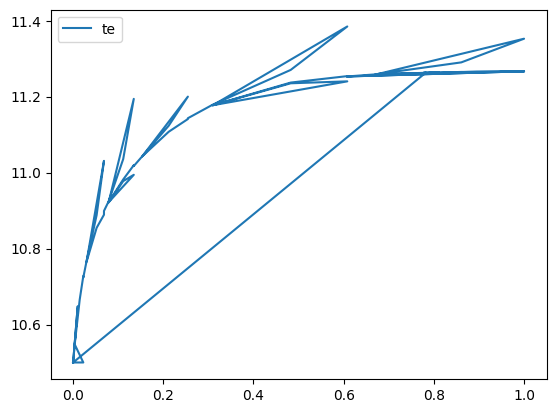

In [ ]:
%matplotlib inline
iter_df = pd.read_csv("ivp_iterations.csv")
# Plot
fig, ax = plt.subplots()
ax.plot(iter_df["t"], iter_df["te"], label="te")
ax.ticklabel_format(axis="y", useOffset=False)
# ax.plot(iter_df["t"], iter_df["ne"], label="ne")
# ax.plot(iter_df["t"], iter_df["dne_dt"], label="ne")
ax.legend()

Plot integration results.

Text(0.5, 1.0, 'Integration of $dT_e/dt$ and $dn_e/dt$')

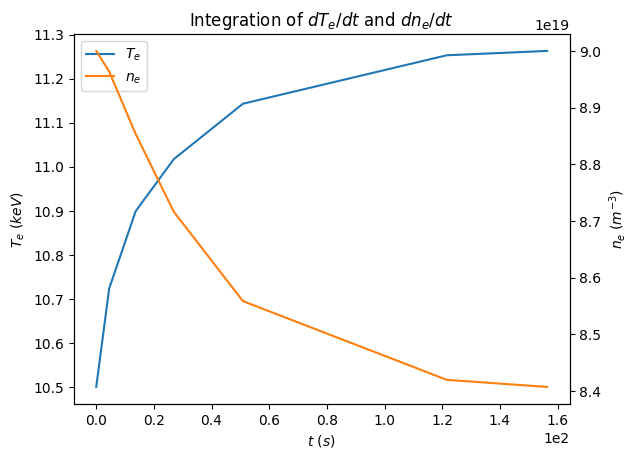

In [6]:
%matplotlib inline
# Plot
fig, ax = plt.subplots()
line1 = ax.plot(t_real, y_real[0, :], label="$T_e$")
ax.set_xlabel("$t$ $(s)$")
ax.set_ylabel("$T_e$ $(keV)$")
ax.ticklabel_format(axis="y", useOffset=False)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
ax2 = ax.twinx()
line2 = ax2.plot(t_real, y_real[1, :], color="C1", label="$n_e$")
ax2.set_ylabel("$n_e$ $(m^{-3})$")
ax2.ticklabel_format(axis="y", useOffset=False)
lns = line1 + line2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=0)
ax.set_title("Integration of $dT_e/dt$ and $dn_e/dt$")

Converges on same solution as optimised solution, despite perturbed initial values. Zoom in to see Te dynamics:

## Multiple integrations: vary initial value

In [12]:
# Parameters to vary
pinj = P_HCD_PRIMARY_EXTRA_HEAT_MW
rfuel = MOLFLOW_PLASMA_FUELLING_REQUIRED
fw = 5.0e-6
triang = 0.5

initial_values_list = [[11.0, 8.5e19], [12.0, 8.0e19], [10.5, 9.0e19]] / scaling
initial_value_sols = []
for initial_values in initial_values_list:
    print(f"Running {initial_values = }")
    sol = solve_ivp(
        fun=derivatives,
        args=(pinj, rfuel, fw, triang),
        t_span=time_span,
        y0=initial_values,
        method="Radau",
        events=detect_steady_state,
    )
    initial_value_sols.append(sol)

pv.f_nd_beam_electron = 0.0
zimp = 0.04332806881016533


Text(0.5, 0.98, 'Integration of $dT_e/dt$ and $dn_e/dt$')

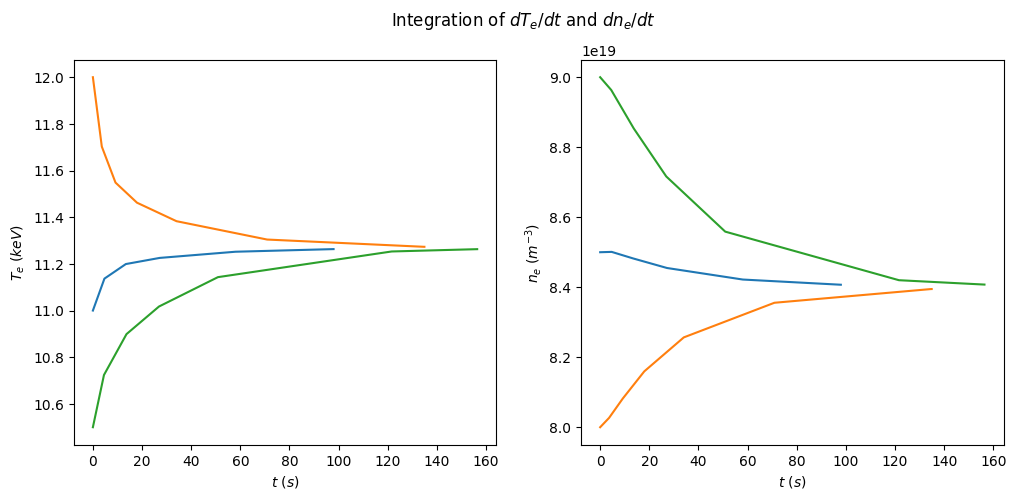

In [13]:
# Plot
fig, axs = plt.subplots(ncols=2)
fig.set_size_inches(12, 5)
for sol in initial_value_sols:
    y_real2 = sol.y * scaling[:, np.newaxis]
    t_real2 = sol.t * t0
    axs[0].plot(t_real2, y_real2[0, :])
    axs[1].plot(t_real2, y_real2[1, :])

axs[0].set_xlabel("$t$ $(s)$")
axs[0].set_ylabel("$T_e$ $(keV)$")
axs[0].ticklabel_format(axis="y", useOffset=False)
axs[1].set_xlabel("$t$ $(s)$")
axs[1].set_ylabel("$n_e$ $(m^{-3})$")
axs[1].ticklabel_format(axis="y", useOffset=False)
fig.suptitle("Integration of $dT_e/dt$ and $dn_e/dt$")

## Vary Pinj, Rfuel

In [14]:
pinj_rfuel_list = [(100.0, 7.5e21), (125.0, 7.5e21), (125.0, 8.0e21)]
initial_values = [10.0, 1.0e20] / scaling
pinj_rfuel_sols = []
for pinj, rfuel in pinj_rfuel_list:
    print(f"Running {initial_values = }")
    sol = solve_ivp(
        fun=derivatives,
        args=(pinj, rfuel, fw, triang),
        t_span=time_span,
        y0=initial_values,
        method="Radau",
        events=detect_steady_state,
    )
    pinj_rfuel_sols.append(sol)

pv.f_nd_beam_electron = 0.0
zimp = 0.04392984804546485


Text(0.5, 0.98, 'Integration of $dT_e/dt$ and $dn_e/dt$ for various $P_{inj}$ and $R_{fuel}$ values')

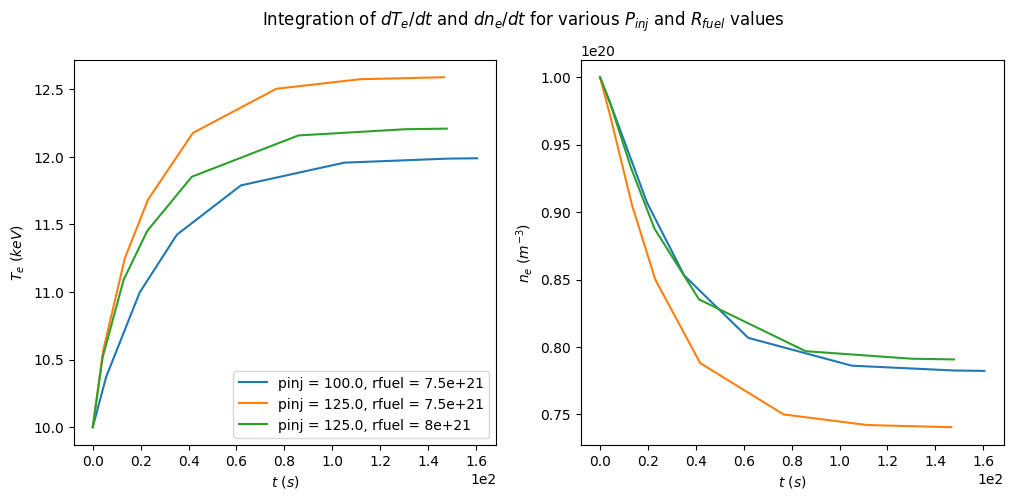

In [15]:
# %matplotlib inline
# Plot
fig, axs = plt.subplots(ncols=2)
fig.set_size_inches(12, 5)
for i, sol in enumerate(pinj_rfuel_sols):
    y_real3 = sol.y * scaling[:, np.newaxis]
    t_real3 = sol.t * t0
    axs[0].plot(
        t_real3,
        y_real3[0, :],
        label=f"pinj = {pinj_rfuel_list[i][0]}, rfuel = {pinj_rfuel_list[i][1]}",
    )
    axs[1].plot(t_real3, y_real3[1, :])

axs[0].set_xlabel("$t$ $(s)$")
axs[0].set_ylabel("$T_e$ $(keV)$")
axs[0].ticklabel_format(axis="y", useOffset=False)
axs[0].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
axs[0].legend()
axs[1].set_xlabel("$t$ $(s)$")
axs[1].set_ylabel("$n_e$ $(m^{-3})$")
axs[1].ticklabel_format(axis="y", useOffset=False)
axs[1].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
fig.suptitle(
    "Integration of $dT_e/dt$ and $dn_e/dt$ for various $P_{inj}$ and $R_{fuel}$ values"
)

Different equilibrium obtained for varying pinj and rfuel: appears to make sense.

## Varying W fraction and triang

In [16]:
unc_list = [(5.0e-6, 0.5), (5.0e-5, 0.5), (5.0e-5, 0.6)]
pinj = 125.0
rfuel = MOLFLOW_PLASMA_FUELLING_REQUIRED
initial_values = [10.0, 1.0e20] / scaling
w_triang_sols = []
for fw, triang in unc_list:
    print(f"Running {initial_values = }")
    sol = solve_ivp(
        fun=derivatives,
        args=(pinj, rfuel, fw, triang),
        t_span=time_span,
        y0=initial_values,
        method="Radau",
        events=detect_steady_state,
    )
    w_triang_sols.append(sol)

pv.f_nd_beam_electron = 0.0
zimp = 0.04689186585540616


Text(0.5, 0.98, 'Integration of $dT_e/dt$ and $dn_e/dt$ for various $f_{W}$ and $\\delta$ values')

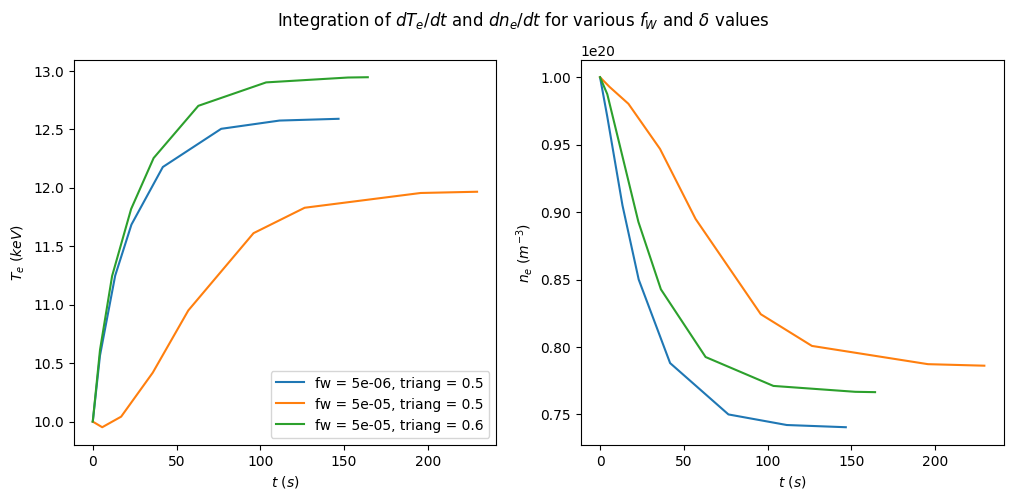

In [17]:
# %matplotlib inline
# Plot
fig, axs = plt.subplots(ncols=2)
fig.set_size_inches(12, 5)
for i, sol in enumerate(w_triang_sols):
    y_real4 = sol.y * scaling[:, np.newaxis]
    t_real4 = sol.t * t0
    axs[0].plot(
        t_real4,
        y_real4[0, :],
        label=f"fw = {unc_list[i][0]}, triang = {unc_list[i][1]}",
    )
    axs[1].plot(t_real4, y_real4[1, :])

axs[0].set_xlabel("$t$ $(s)$")
axs[0].set_ylabel("$T_e$ $(keV)$")
axs[0].ticklabel_format(axis="y", useOffset=False)
axs[0].legend()
axs[1].set_xlabel("$t$ $(s)$")
axs[1].set_ylabel("$n_e$ $(m^{-3})$")
axs[1].ticklabel_format(axis="y", useOffset=False)
fig.suptitle(
    "Integration of $dT_e/dt$ and $dn_e/dt$ for various $f_{W}$ and $\delta$ values"
)

## Direction field

May be helpful to experiment with normalisation to show both gradients, despite very different timescales.

In [18]:
n = 10
te = np.linspace(7.0, 16.0, n) / scaling[0]
ne = np.linspace(6.0e19, 12.0e19, n) / scaling[1]
tes, nes = np.meshgrid(te, ne)
dte_dts = np.zeros_like(tes)
dne_dts = np.zeros_like(tes)

pinj = 250.0
rfuel = 9.0e21
triang = 0.5
fw = 5.0e-06

for i in range(tes.shape[0]):
    for j in range(nes.shape[1]):
        dte_dts[i, j], dne_dts[i, j] = derivatives(
            None, [tes[i, j], nes[i, j]], pinj, rfuel, fw, triang
        )

# print(dte_dts)
# print(dne_dts)

pv.f_nd_beam_electron = 0.0
zimp = 0.04517277130949733


2.915199752063759
-1.1798403713855097


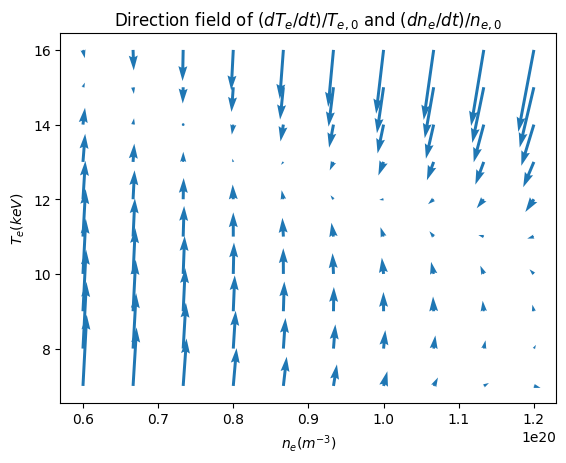

In [19]:
# Non-normalised gradients
fig, ax = plt.subplots()
tes_real = tes * scaling[0]
nes_real = nes * scaling[1]
dte_dts_real = dte_dts * scaling[0]
dne_dts_real = dne_dts * scaling[1]
ax.quiver(nes_real, tes_real, dne_dts, dte_dts, color="C0")
# ax.quiver(nes, tes, dne_dts, dte_dts, color="C0")
ax.set_xlabel("$n_e (m^{-3})$")
ax.set_ylabel("$T_e (keV)$")
ax.set_title("Direction field of $(dT_e/dt)/T_{e, 0}$ and $(dn_e/dt)/n_{e, 0}$")

print(np.average(dte_dts))
print(np.average(dne_dts))

2.915199752063759
-1.1798403713855097


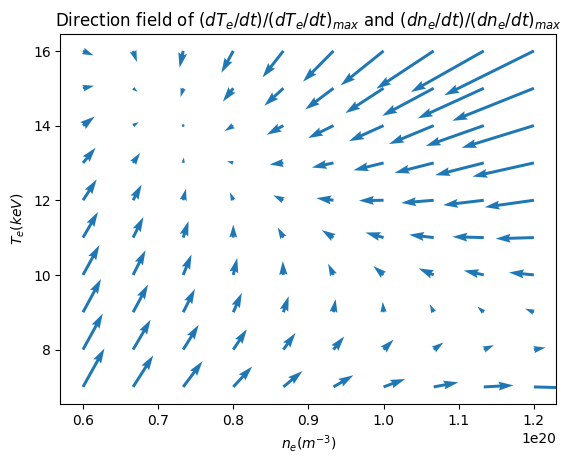

In [20]:
# Normalise gradients
dte_dts_norm = dte_dts / dte_dts.max()
dne_dts_norm = dne_dts / dne_dts.max()

fig, ax = plt.subplots()
ax.quiver(nes_real, tes_real, dne_dts_norm, dte_dts_norm, color="C0")
# ax.quiver(nes, tes, dne_dts, dte_dts, color="C0")
ax.set_xlabel("$n_e (m^{-3})$")
ax.set_ylabel("$T_e (keV)$")
ax.set_title(
    "Direction field of $(dT_e/dt)/(dT_e/dt)_{max}$ and $(dn_e/dt)/(dn_e/dt)_{max}$"
)

print(np.average(dte_dts))
print(np.average(dne_dts))

Both initial vectors achieve the same solution. This differs to the NL solve approach, where they result in completely different solutions.